In [31]:
import mujoco as mj
import mediapy as media
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [46]:
df=pd.read_csv(os.path.join("data",'robot_data_final.csv'))
unique_series_ids = df['series_id'].unique()
print(unique_series_ids)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [49]:
series_1_data = df[df['series_id'] == 4]
series_1_data.head()

,time,series_id,angle1,angle2,speed1,speed2,torque1,torque2,target1,target2
161,0.051273,4,157.76,-92.05,0,0,0.0720,-0.0945,117.11,-198.33
162,0.102181,4,157.78,-92.06,0,0,0.0630,-0.0900,117.11,-198.33
163,0.153794,4,157.78,-92.07,0,0,0.0765,-0.0900,117.11,-198.33
164,0.205325,4,157.78,-92.07,0,0,0.0810,-0.0990,117.11,-198.33
165,0.256170,4,157.78,-92.07,0,0,0.0720,-0.0990,117.11,-198.33


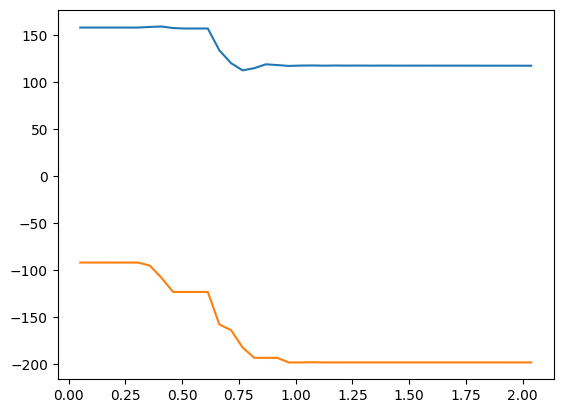

In [50]:

plt.plot(series_1_data["time"],series_1_data["angle1"])
plt.plot(series_1_data["time"],series_1_data["angle2"])

In [11]:
def generate_mujoco_xml(timestep,o1x,o1y,o2x,o2y,L_p1,L_p2,L_d1,L_d2,link_width,link_height,link_separation,rotor1_D,rotor2_D,rotor1_H,rotor2_H,
                        max_torque,q0,
                        inertia_rotor1,inertia_rotor2,inertia_p1,inertia_p2,inertia_d1,inertia_d2,
                        com_offset_p1,com_offset_p2,com_offset_d1,com_offset_d2,
                        mass_rotor1,mass_rotor2,mass_p1,mass_p2,mass_d1,mass_d2,
                        damping_bp1,damping_bp2,damping_p1d1,damping_p2d2,
                        dryfrict_bp1,dryfrict_bp2,dryfrict_p1d1,dryfrict_p2d2):
    xml_template = f"""
<mujoco model="parallel_5_bar_mechanism">
    <compiler angle="degree"/>
    <option gravity="0 0 -9.81" integrator="RK4" timestep="{timestep}" />
    <asset>
        <texture type="skybox" builtin="gradient" rgb1=".4 .5 .6" rgb2="0 0 0" width="100" height="100"/>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3" rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <light cutoff="100" diffuse="1 1 1" dir="-0 0 -1.3" directional="true" exponent="1" pos="0 0 1.3" specular=".1 .1 .1"/>
        <geom name="worldbody" size="1 1 .01" pos="0 0 -.2" type="plane" material="grid"/>
        <body name="base" pos="0 0 0">
            <body name="proximal1" pos="{o1x} {o1y} {1.5*link_height+1.5*link_separation}" euler="0 0 {np.rad2deg(q0[0])}">
                <inertial pos='{L_p1/2+com_offset_p1} 0 0' mass='{mass_p1}' diaginertia='{inertia_p1} {inertia_p1} {inertia_p1}'/>
                <body name="rotor1" pos="0 0 {rotor1_H/2+link_height/2}"> 
                    <geom type="cylinder" size="{rotor1_D/2} {rotor1_H/2}" rgba="0 0 0 1"/>
                    <inertial pos="0 0 0" mass="{mass_rotor1}" diaginertia='{inertia_rotor1} {inertia_rotor1} {inertia_rotor1}' />
                </body>
                <joint name="joint1" type="hinge" axis="0 0 1" pos="0 0 0"   damping="{damping_bp1}" frictionloss="{dryfrict_bp1}" stiffness="0" ref="{np.rad2deg(q0[0])}"/>
                <geom name="proximal1" type="box" size="{(L_p1)/2} {link_width/2} {link_height/2}" pos="{L_p1/2} 0 0" rgba="1 0 0 1"/>
                <body name="distal1" pos="{L_p1} 0 {-link_height-link_separation}" euler="0 0 {np.rad2deg(q0[1]-q0[0])}">
                    <inertial pos='{L_d1/2+com_offset_d1} 0 0' mass='{mass_d1}' diaginertia='{inertia_d1} {inertia_d1} {inertia_d1}'/>
                    <joint name="joint3" type="hinge" axis="0 0 1" pos="0 0 0"  damping="{damping_p1d1}" frictionloss="{dryfrict_p1d1}" stiffness="0" ref="{np.rad2deg(q0[1]-q0[0])}"/>
                    <geom name="distal1" type="box" size="{L_d1/2} {link_width/2} {link_height/2}" pos="{L_d1/2} 0 0" rgba="0 1 0 1"/>
                    <body name="end_effector" pos="{L_d1} 0 0">
					    <geom contype="0" name="end_effector" pos="0 0 0" rgba="0.0 0.8 0.6 1" size=".001" type="sphere"/>
				    </body>
                </body>
            </body>
            <body name="proximal2" pos="{o2x} {o2y} {-1.5*link_height-1.5*link_separation}" euler="0 0 {np.rad2deg(q0[3])}">
                <inertial pos='{-L_p2/2+com_offset_p2} 0 0' mass='{mass_p2}' diaginertia='{inertia_p2} {inertia_p2} {inertia_p2}'/>
                <body name="rotor2" pos="0 0 -{rotor2_H/2+link_height/2}"> 
                    <geom type="cylinder" size="{rotor2_D/2} {rotor2_H/2}" rgba="0 0 0 1"/>
                    <inertial pos="0 0 0" mass="{mass_rotor2}" diaginertia='{inertia_rotor2} {inertia_rotor2} {inertia_rotor2}' />
                </body>
                <joint name="joint2" type="hinge" axis="0 0 1" pos="0 0 0"  damping="{damping_bp2}" frictionloss="{dryfrict_bp2}" stiffness="0"  ref="{np.rad2deg(q0[3])}"/>
                <geom name="proximal2" type="box" size="{L_p2/2} {(link_width)/2} {link_height/2}" pos="{-L_p2/2} 0 0" rgba="1 0 0 1"/>
                <body name="distal2" pos="{-L_p2} 0 {link_height+link_separation}" euler="0 0 {np.rad2deg(q0[2]-q0[3])}">
                    <inertial pos='{-L_d2/2+com_offset_d2} 0 0' mass='{mass_d2}' diaginertia='{inertia_d2} {inertia_d2} {inertia_d2}'/>
                    <joint name="joint4" type="hinge" axis="0 0 1" pos="0 0 0"  damping="{damping_p2d2}" frictionloss="{dryfrict_p2d2}" stiffness="0" ref="{np.rad2deg(q0[2]-q0[3])}"/>
                    <geom name="distal2" type="box" size="{L_d2/2} {link_width/2} {link_height/2}" pos="{-L_d2/2} 0 0" rgba="0 1 0 1"/>
                </body>
            </body>
        </body>
        <body name="target" pos=".125 .125 0">
			<joint armature="0" axis="1 0 0" damping="0" limited="true" name="target_x" pos="0 0 0" range="-1 1" ref=".125" stiffness="0" type="slide"/>
			<joint armature="0" axis="0 1 0" damping="0" limited="true" name="target_y" pos="0 0 0" range="-1 1" ref=".125" stiffness="0" type="slide"/>
			<geom conaffinity="0" contype="0" name="target" pos="0 0 0" rgba="0.9 0.2 0.2 1" size="0.01" type="sphere"/>
	    </body>
    </worldbody>
    <equality>
		<connect anchor="{L_d1} 0 0" body1="distal1" body2="distal2" name="equality_constraint"/>
	</equality>
    <sensor>
		<framepos objtype="body" objname="end_effector"/>
		<framelinvel objtype="body" objname="end_effector"/>
	</sensor>
    <actuator>
        <!position joint="joint1" ctrllimited="true"  ctrlrange="0 3.14" kp="3" kv="0.1"/>
        <!position joint="joint2" ctrllimited="true"  ctrlrange="-3.14 0" kp="3" kv="0.1"/>
        <motor joint="joint1" ctrllimited="true"  ctrlrange="-{max_torque} {max_torque}"/>
        <motor joint="joint2" ctrllimited="true"  ctrlrange="-{max_torque} {max_torque}"/>
    </actuator>
</mujoco>
"""
    return xml_template

In [16]:
def simplified_xml(inertia_p,inertia_d,dry_friction_pd,dry_friction_bp,damping_pd,damping_bp):
    timestep=0.01
    scale=0.5
    o1x=-0.075*scale
    o1y=0*scale
    o2x=0.075*scale
    o2y=0*scale
    L_p1=0.2*scale
    L_p2=0.2*scale
    L_d1=0.4*scale
    L_d2=0.4*scale
    link_width=0.02
    link_height=0.026
    link_separation=0.003
    max_torque=1.6

    q0=[2.356194490192345,
        0.999107158546108,
        -0.999107158546108,
        -2.356194490192345]

    inertia_p1=inertia_p
    inertia_p2=inertia_p
    inertia_d1=inertia_d
    inertia_d2=inertia_d

    mass_p1=0.65639730
    mass_p2=mass_p1
    mass_d1=0.25965946
    mass_d2=mass_d1

    damping_bp1=damping_bp
    damping_bp2=damping_bp
    damping_p1d1=damping_pd
    damping_p2d2=damping_pd

    dryfrict_bp1=dry_friction_bp
    dryfrict_bp2=dry_friction_bp
    dryfrict_p1d1=dry_friction_pd
    dryfrict_p2d2=dry_friction_pd

    rotor1_D=89e-3# From Motor Spec
    rotor2_D=rotor1_D
    rotor1_H=28e-3# From Motor Spec
    rotor2_H=rotor1_H

    inertia_rotor1=0.0003271 # From Motor Spec
    inertia_rotor2=inertia_rotor1

    mass_rotor1=0.65
    mass_rotor2=mass_rotor1

    com_offset_p1=-1e-3
    com_offset_p2=-com_offset_p1
    com_offset_d1=0
    com_offset_d2=-com_offset_d1
    
    return generate_mujoco_xml(timestep,o1x,o1y,o2x,o2y,L_p1,L_p2,L_d1,L_d2,link_width,link_height,link_separation,rotor1_D,rotor2_D,rotor1_H,rotor2_H,
                        max_torque,q0,
                        inertia_rotor1,inertia_rotor2,inertia_p1,inertia_p2,inertia_d1,inertia_d2,
                        com_offset_p1,com_offset_p2,com_offset_d1,com_offset_d2,
                        mass_rotor1,mass_rotor2,mass_p1,mass_p2,mass_d1,mass_d2,
                        damping_bp1,damping_bp2,damping_p1d1,damping_p2d2,
                        dryfrict_bp1,dryfrict_bp2,dryfrict_p1d1,dryfrict_p2d2)

In [ ]:
inertia_p=0.00038976
inertia_d=0.00158076

dry_friction_pd=0.1
dry_friction_bp=0.1

damping_pd=0
damping_bp=0

xml=simplified_xml(inertia_p,inertia_d,dry_friction_pd,dry_friction_bp,damping_pd,damping_bp)

In [18]:

model = mj.MjModel.from_xml_string(xml)
data = mj.MjData(model)

# enable joint visualization option:
scene_option = mj.MjvOption()

duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mj.mj_resetData(model, data)
with mj.Renderer(model) as renderer:
  while data.time < duration:
    mj.mj_step(model, data)
    data.ctrl[0]=1
    if len(frames) < data.time * framerate:
      renderer.update_scene(data, scene_option=scene_option)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.
